### 課題

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import japanize_matplotlib

from sklearn.datasets import make_regression               # データセットの生成
from sklearn.model_selection import train_test_split       # データセットの分割
from sklearn.preprocessing import StandardScaler as scaler # データの標準化
from sklearn.linear_model import Ridge, Lasso              # 線形回帰モデル
from sklearn.metrics import mean_squared_error as mse      # モデルの評価指標(MSE)

In [31]:
# ①データ生成
X, y = make_regression(
    n_samples = 100,   # サンプル数
    n_features = 30,   # 特徴量の数
    n_informative = 5, # 有効次元数
    noise = 20,        # ノイズの大きさ
    random_state = 0   # 乱数シード
)

# ②データセットの分割
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# ③データの標準化
scaler = scaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

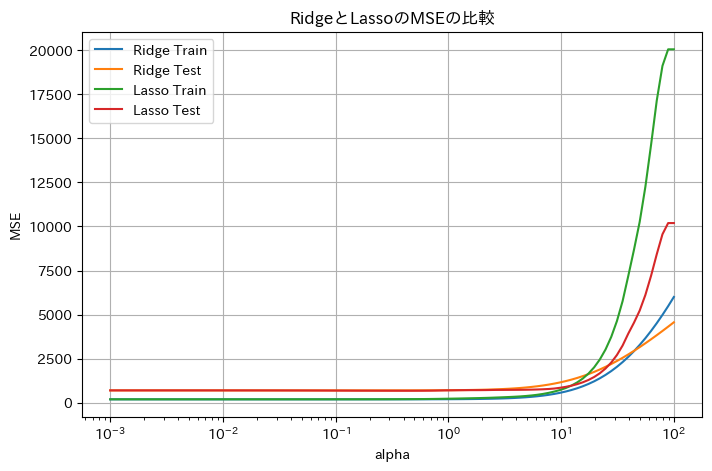

In [32]:
# 課題1
alphas = np.logspace(-3, 2, 100) # 10^-3から10^2まで100段階

ridge_train = []
ridge_test = []
lasso_train = []
lasso_test = []

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    ridge.fit(X_train, y_train)

    ridge_train.append(
        mse(y_train, ridge.predict(X_train))
    )
    ridge_test.append(
        mse(y_test, ridge.predict(X_test))
    )

    lasso = Lasso(alpha=alpha)
    lasso.fit(X_train, y_train)

    lasso_train.append(
        mse(y_train, lasso.predict(X_train))
    )
    lasso_test.append(
        mse(y_test, lasso.predict(X_test))
    )

plt.figure(figsize=(8,5))
plt.plot(alphas, ridge_train, label='Ridge Train')
plt.plot(alphas, ridge_test, label='Ridge Test')
plt.plot(alphas, lasso_train, label='Lasso Train')
plt.plot(alphas, lasso_test, label='Lasso Test')

plt.xscale('log')
plt.xlabel('alpha')
plt.ylabel('MSE')
plt.legend()
plt.grid()
plt.title('RidgeとLassoのMSEの比較')
plt.show()

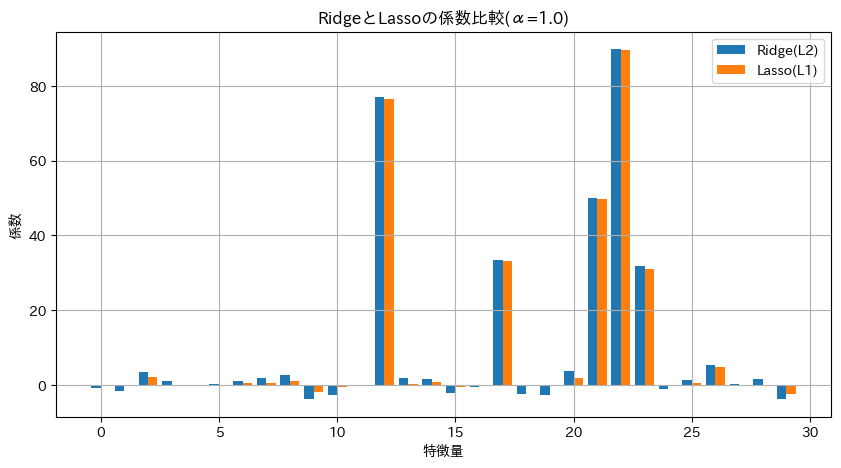

Ridge(L2)係数=0の数: 0
Lasso(L1)係数=0の数: 11


In [11]:
alpha = 1.0
ridge = Ridge(alpha=alpha)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=alpha)
lasso.fit(X_train, y_train)

plt.figure(figsize=(10,5))

plt.bar(
    np.arange(len(ridge.coef_)) - 0.2,
    ridge.coef_,
    width=0.4,
    label='Ridge(L2)'
)

plt.bar(
    np.arange(len(lasso.coef_)) + 0.2,
    lasso.coef_,
    width=0.4,
    label='Lasso(L1)'
)
plt.xlabel('特徴量')
plt.ylabel('係数')
plt.title(f'RidgeとLassoの係数比較(α={alpha})')
plt.legend()
plt.grid()
plt.show()

print(f"Ridge(L2)係数=0の数: {np.sum(ridge.coef_ == 0)}")
print(f"Lasso(L1)係数=0の数: {np.sum(lasso.coef_ == 0)}")

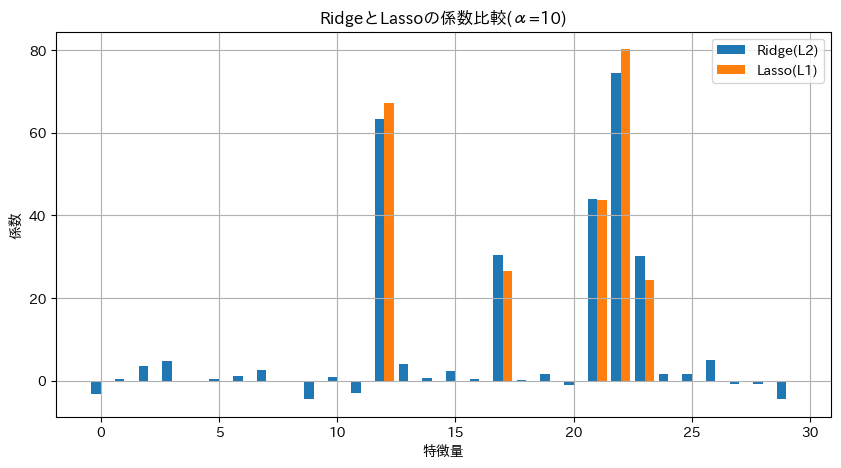

Ridge(L2)係数=0の数: 0
Lasso(L1)係数=0の数: 25


In [12]:
alpha = 10
ridge = Ridge(alpha=alpha)
ridge.fit(X_train, y_train)

lasso = Lasso(alpha=alpha)
lasso.fit(X_train, y_train)

plt.figure(figsize=(10,5))

plt.bar(
    np.arange(len(ridge.coef_)) - 0.2,
    ridge.coef_,
    width=0.4,
    label='Ridge(L2)'
)

plt.bar(
    np.arange(len(lasso.coef_)) + 0.2,
    lasso.coef_,
    width=0.4,
    label='Lasso(L1)'
)
plt.xlabel('特徴量')
plt.ylabel('係数')
plt.title(f'RidgeとLassoの係数比較(α={alpha})')
plt.legend()
plt.grid()
plt.show()

print("Ridge(L2)係数=0の数:", np.sum(ridge.coef_ == 0))
print("Lasso(L1)係数=0の数:", np.sum(lasso.coef_ == 0))

### 考察
αを大きくすると正則化が強くなり、モデルが単純化されるためMSEが増加した。特にLassoはαの増加に伴うMSEへの影響が大きく、L1正則化が係数を強く0へ近づける性質を示していた。確かに、α=1とα=10で比較しても、後者の方が係数が0である数が多かった。一方、Ridgeでは両者でも係数が0になることがなく、全ての係数を小さくしながらモデルの複雑さを抑える傾向が見られた。このことからLassoは特徴量選択に適しており、Ridgeは全ての特徴量に対しバランスよく過学習を抑える手法であることが確認できた。

### AIの使用
ライブラリの使用方法や関数の引数の確認に利用した。また、結果の解釈のための参考とした。